# Online Tuning — BC vs CQL with a quick refinement (Juan's new data)
Compares a **BC-initialised** actor (BC trunk + expert-PI head) against the **trained CQL policy**, each given a *short* online DDPG refinement (~50 episodes, no gain search) on Juan's 4 new days, then evaluated on those days. Deliberately lighter than the DDPG/TD3 gain-search package.

In [ ]:
# ── Setup: shared library (../main_script) + this folder's config ─────────────
import os, sys, copy, time
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
sys.path.insert(0, os.getcwd())                                            # for: import config
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), os.pardir)))  # reach ../main_script
from main_script import *
import config as cfg
from config import *
configure(cfg); set_seed(SEED)
print("Device:", DEVICE, "| gain box", GAIN_LOW, "->", GAIN_HIGH)

# datasets + episode sampler (folder-specific)
train_datasets   = [load_dataset(f) for f in JUAN_FILES]
VAL_FILE         = JUAN_FILES[-1]
episode_datasets = [load_dataset(f) for f in JUAN_FILES if f != VAL_FILE]
val_eval_days    = [d for d in train_datasets if d["name"] == VAL_FILE]
def get_episode_data(datasets, ep_steps=SHORT_EP_STEPS):
    idx = int(np.random.choice(len(datasets))); full = datasets[idx]
    ms = max(0, full["N"] - ep_steps - 1); start = np.random.randint(0, ms + 1) if ms > 0 else 0
    return window(full, start, ep_steps)
print(f"Quick-refine on {len(episode_datasets)} Juan days; VAL = {VAL_FILE}")


In [9]:
# ══════════ QUICK online DDPG refinement — BC-init vs CQL-init ══════════
# Method 1 (BC):  actor = BC trunk + expert-PI head  (bc_cirl_setpoint_anti_windup_best.pt)
# Method 2 (CQL): actor = the trained CQL policy      (cql_cirl_actor_best.pt)
# Each gets the SAME short DDPG refinement on Juan's days (critic-driven, no gain search).
BC_CKPT  = 'bc_cirl_setpoint_anti_windup_best.pt'
CQL_CKPT = 'cql_cirl_actor_best.pt'

def build_bc_agent():
    a = DDPG(warm_start=True)                 # warm_start_actor: BC trunk + expert head
    return a

def build_cql_agent():
    a = DDPG(warm_start=False)                # random init, then load the full CQL policy
    a.actor.load_state_dict(torch.load(os.path.join(SAVE_DIR, CQL_CKPT), map_location=DEVICE, weights_only=True))
    a.actor_target = copy.deepcopy(a.actor); a.actor_target.eval()
    print(f"[cql] policy loaded from {CQL_CKPT}")
    return a

def quick_refine(agent, name, episodes=QUICK_EPISODES):
    """Short critic-driven DDPG refine on Juan's episode days. Keeps the BEST-validation
    checkpoint, initialised from the RAW policy so the result is never worse than the start."""
    buffer = ReplayBuffer(); noise = OUNoise(sigma=0.12, sigma_min=0.02, decay=0.999)
    agent.bc_weight = 0.0
    vm0, vr0, vo0 = eval_actor(agent.actor, val_eval_days)
    best_obj = vm0 + OVERSHOOT_WEIGHT * vo0
    best_w   = {k: v.clone() for k, v in agent.actor.state_dict().items()}
    hist = {'ep': [0], 'val_mae': [vm0], 'val_reward': [vr0]}
    print(f"[{name}] raw val MAE={vm0:.3f} ovr={vo0:.3f} -> refining {episodes} ep...")
    gstep = 0
    for ep in range(1, episodes + 1):
        data = get_episode_data(episode_datasets); env = SolarFieldEnv(data)
        obs = env.reset(); done = False
        while not done:
            a = agent.act(obs, noise=noise)
            obs2, r, done, info = env.step(a); buffer.add(obs, a, r, obs2, done); gstep += 1
            if gstep >= WARMUP_STEPS and gstep % UPDATE_EVERY == 0:
                for _ in range(UPDATES_PER_CYCLE): agent.update(buffer, BATCH_SIZE)
            obs = obs2; noise.step()
        vm, vr, vo = eval_actor(agent.actor, val_eval_days)
        hist['ep'].append(ep); hist['val_mae'].append(vm); hist['val_reward'].append(vr)
        vobj = vm + OVERSHOOT_WEIGHT * vo
        if vobj < best_obj:
            best_obj = vobj; best_w = {k: v.clone() for k, v in agent.actor.state_dict().items()}
    agent.actor.load_state_dict(best_w); agent.actor.eval()
    vm1, vr1, vo1 = eval_actor(agent.actor, val_eval_days)
    print(f"[{name}] refined val MAE={vm1:.3f} ovr={vo1:.3f}")
    return agent.actor, hist

# raw baselines (unrefined)
raw_cql = Actor().to(DEVICE)
raw_cql.load_state_dict(torch.load(os.path.join(SAVE_DIR, CQL_CKPT), map_location=DEVICE, weights_only=True)); raw_cql.eval()

print("\n=== Method 1: BC warm-start -> quick DDPG refine ===")
agent_bc  = build_bc_agent()
bc_raw    = copy.deepcopy(agent_bc.actor).eval()   # raw warm-start (== Expert PI) BEFORE refining
bc_refined,  bc_hist  = quick_refine(agent_bc,  'BC')
print("\n=== Method 2: CQL warm-start -> quick DDPG refine ===")
agent_cql = build_cql_agent(); cql_refined, cql_hist = quick_refine(agent_cql, 'CQL')

torch.save(bc_refined.state_dict(),  os.path.join(SAVE_DIR, 'online_tuning_bc_refined.pt'))
torch.save(cql_refined.state_dict(), os.path.join(SAVE_DIR, 'online_tuning_cql_refined.pt'))
print("\nrefined policies saved to policies/.")



=== Method 1: BC warm-start -> quick DDPG refine ===
[warm-start] BC trunk loaded from bc_cirl_setpoint_anti_windup_best.pt
[warm-start] head re-centred to START_GAIN (expert) Kp=-0.5 Ki=-0.00167
[BC] raw val MAE=0.831 ovr=4.935 -> refining 50 ep...
[BC] refined val MAE=0.669 ovr=4.765

=== Method 2: CQL warm-start -> quick DDPG refine ===
[cql] policy loaded from cql_cirl_actor_best.pt
[CQL] raw val MAE=0.244 ovr=3.891 -> refining 50 ep...
[CQL] refined val MAE=0.169 ovr=3.650

refined policies saved to policies/.


In [10]:
# ── Comparison table on Juan's 4 days ────────────────────────────────────────
CONTROLLERS = [
    ('Expert PI',                  'expert'),
    ('BC raw (Method-1 start)',    bc_raw),
    ('CQL raw (Method-2 start)',   raw_cql),
    ('Method 1: BC -> refined',    bc_refined),
    ('Method 2: CQL -> refined',   cql_refined),
]

def eval_on_juan(actor_or_expert):
    maes=[]; rmses=[]; ovrs=[]
    for ds in train_datasets:
        tr = dataset_tref(ds['name'])
        if actor_or_expert == 'expert':
            T, _ = rollout_expert(ds)
        else:
            T, _, _ = rollout_full(actor_or_expert, ds)
        m, rm = mae_rmse(T, tr); maes.append(m); rmses.append(rm); ovrs.append(peak_overshoot(T, tr))
    return np.mean(maes), np.mean(rmses), np.mean(ovrs)

print(f"{'controller':30s} {'MAE':>7} {'RMSE':>7} {'overshoot':>10}")
print('-' * 60)
rows = []
for name, ctrl in CONTROLLERS:
    m, rm, ov = eval_on_juan(ctrl)
    rows.append((name, m, rm, ov))
    print(f"{name:30s} {m:7.3f} {rm:7.3f} {ov:10.3f}")
print('-' * 60)
print("(Method-1 raw start == Expert PI, since the BC head is re-centred to the expert gains.)")


controller                         MAE    RMSE  overshoot
------------------------------------------------------------
Expert PI                        1.224   1.731      5.924
BC raw (Method-1 start)          1.224   1.731      5.924
CQL raw (Method-2 start)         0.243   0.501      3.674
Method 1: BC -> refined          0.978   1.414      5.492
Method 2: CQL -> refined         0.180   0.419      3.273
------------------------------------------------------------
(Method-1 raw start == Expert PI, since the BC head is re-centred to the expert gains.)


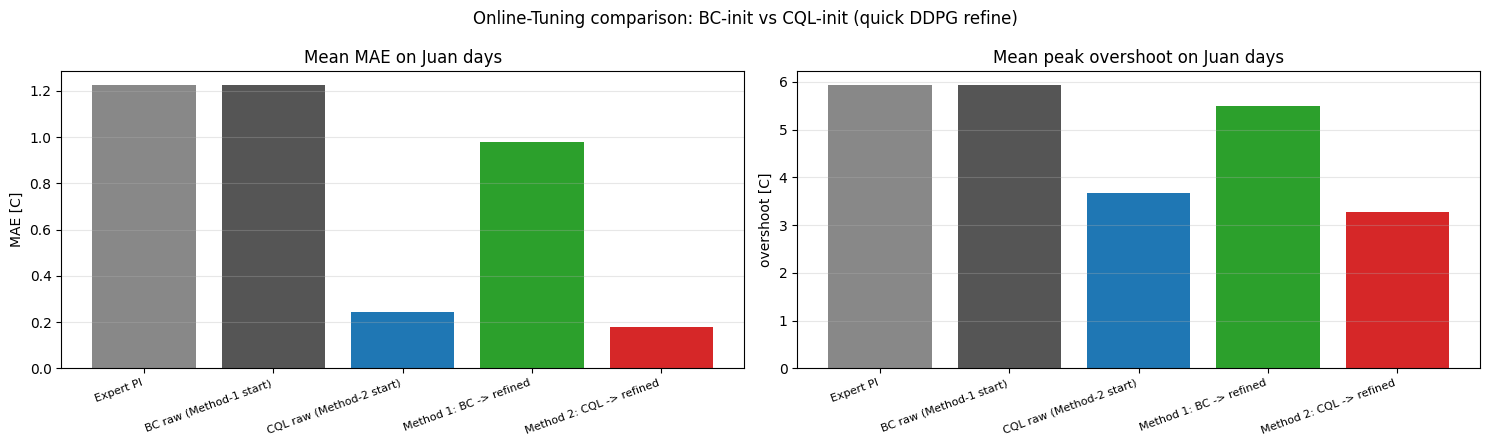

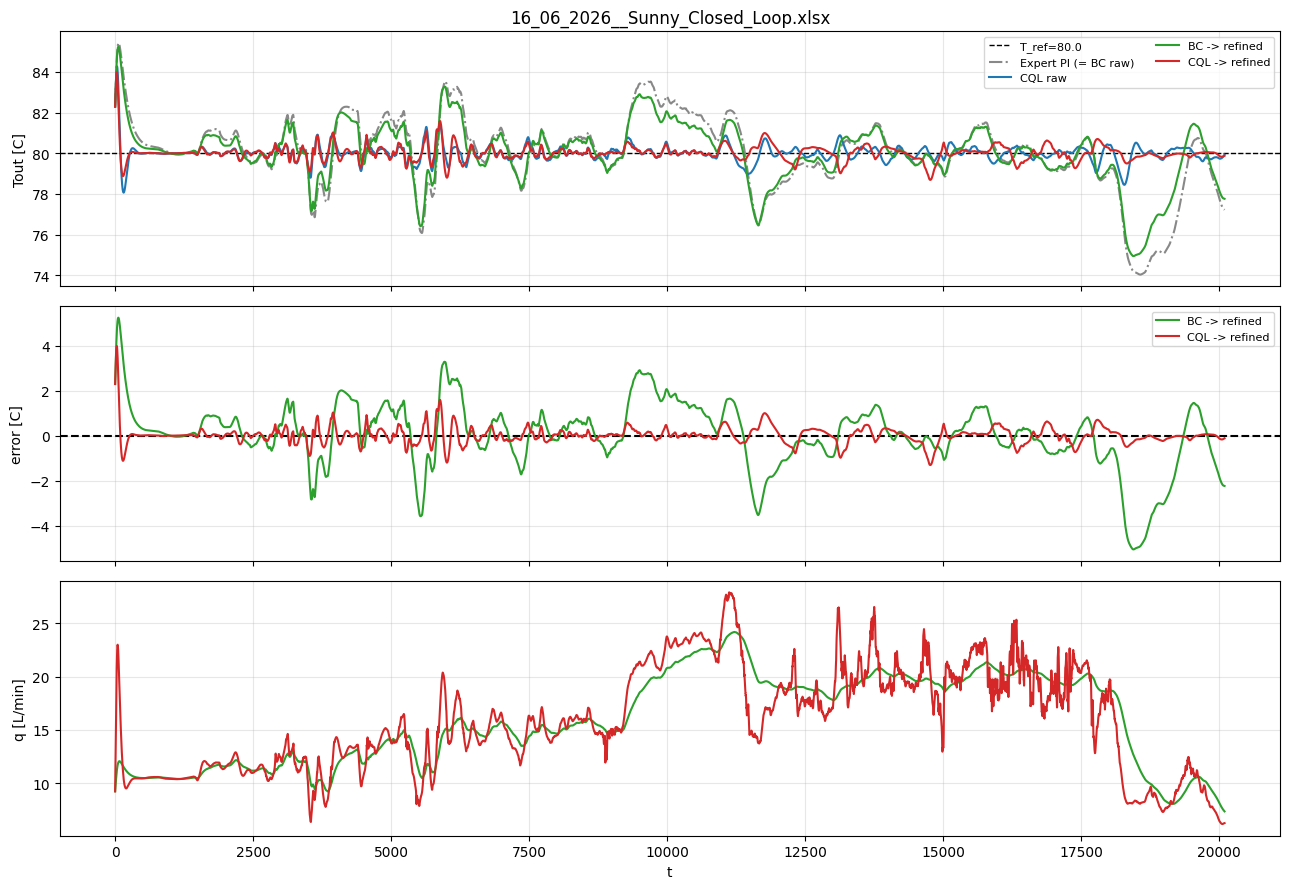

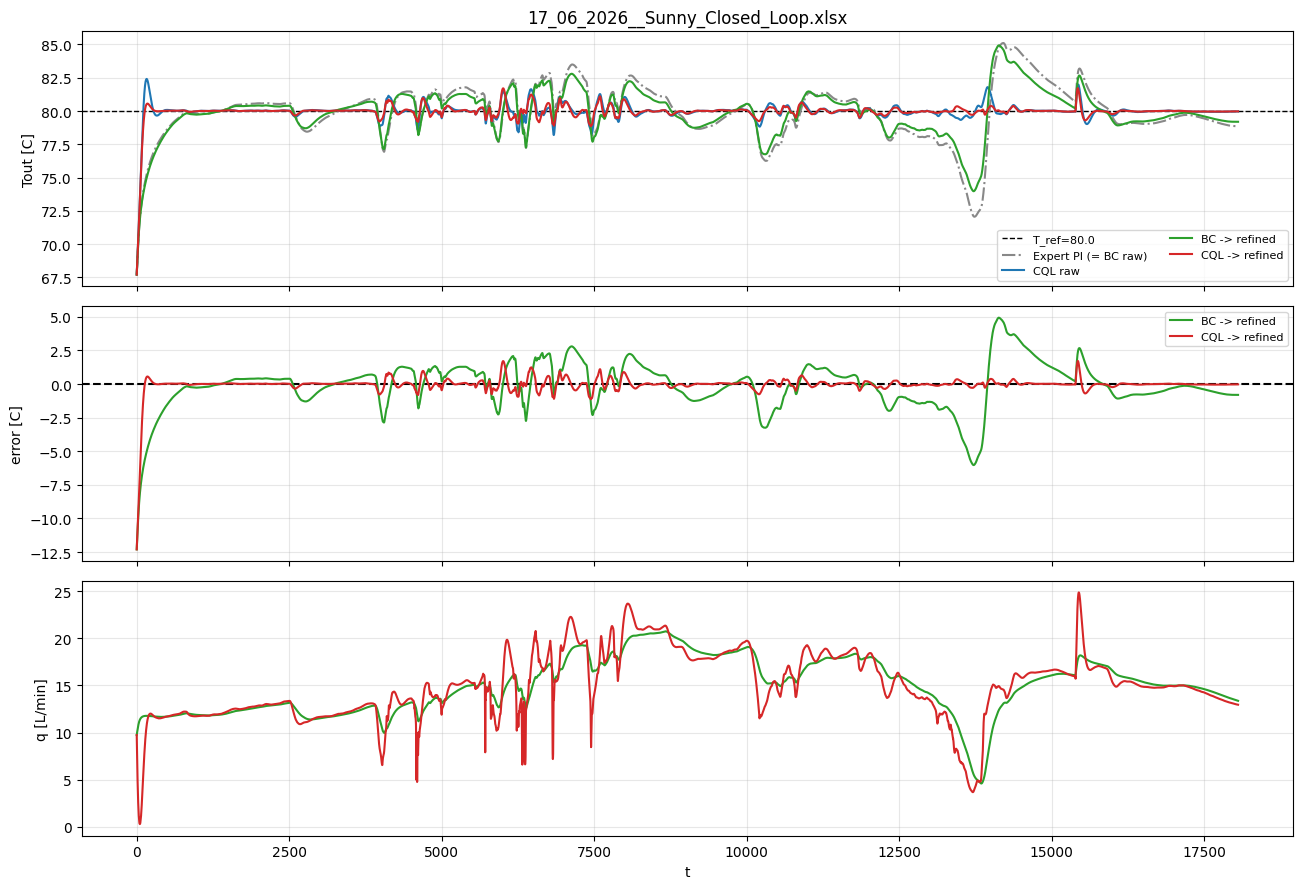

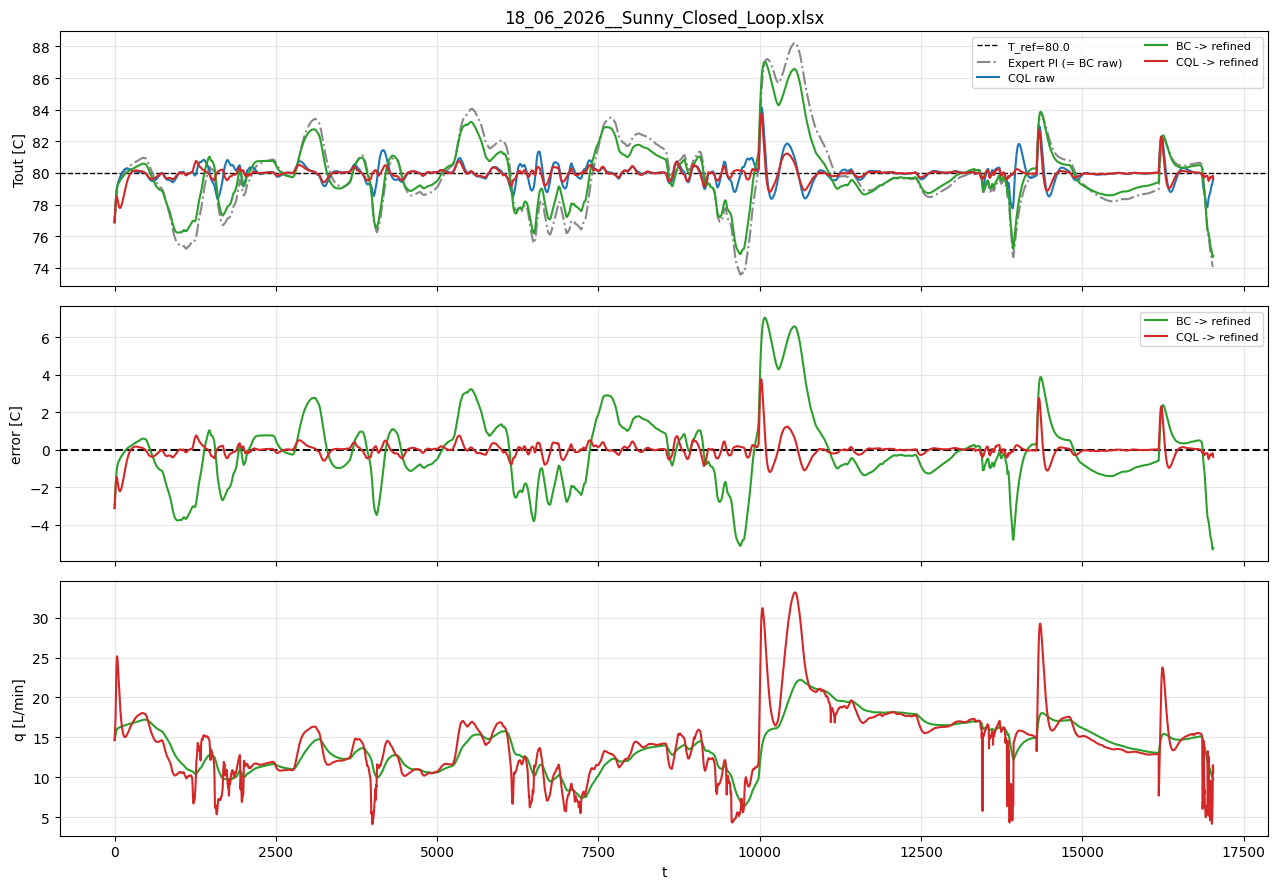

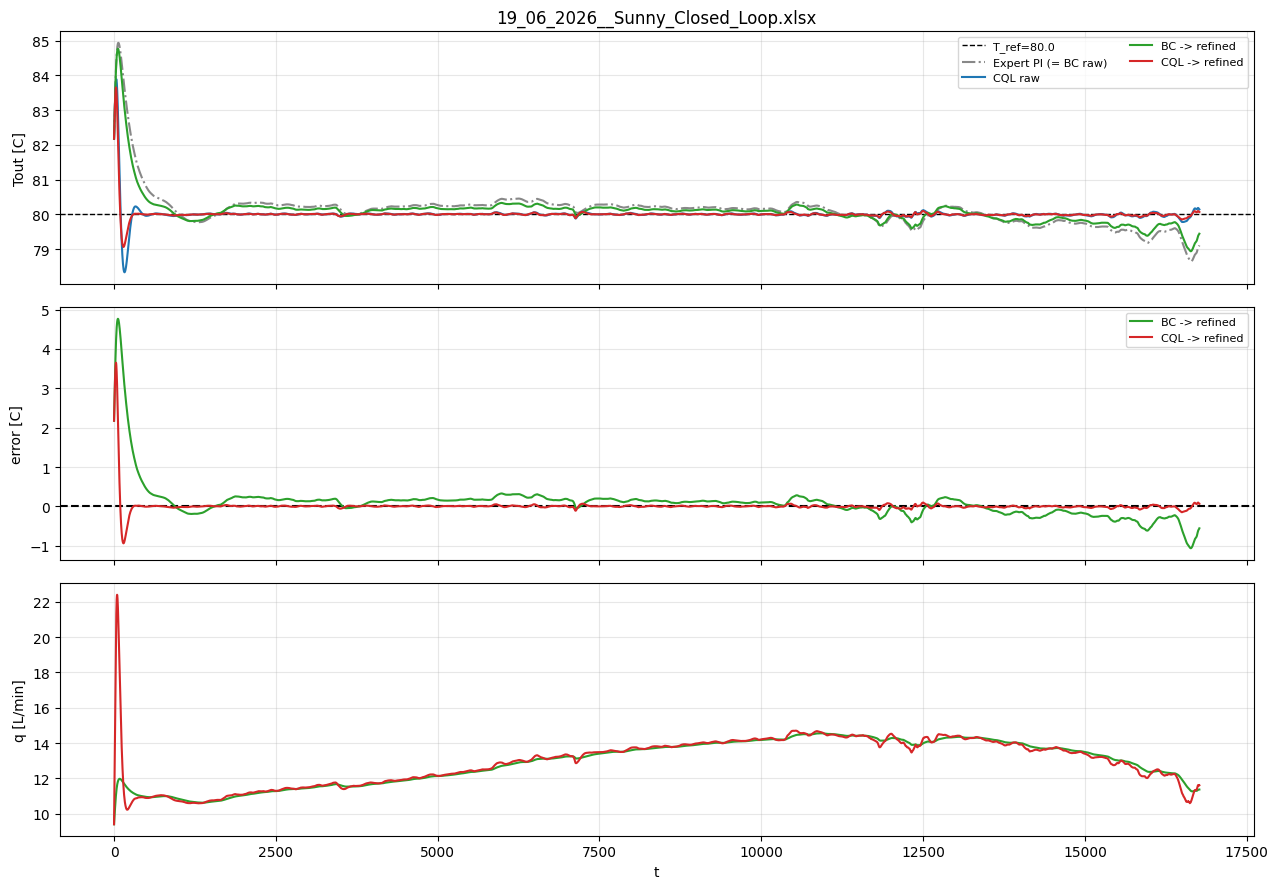

In [11]:
# ── Bar chart + per-Juan-day tracking ────────────────────────────────────────
names = [r[0] for r in rows]; maes = [r[1] for r in rows]; ovrs = [r[3] for r in rows]
x = np.arange(len(names)); colors = ['#888888', '#555555', '#1f77b4', '#2ca02c', '#d62728']
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].bar(x, maes, color=colors); ax[0].set_ylabel('MAE [C]'); ax[0].set_title('Mean MAE on Juan days')
ax[1].bar(x, ovrs, color=colors); ax[1].set_ylabel('overshoot [C]'); ax[1].set_title('Mean peak overshoot on Juan days')
for a in ax:
    a.set_xticks(x); a.set_xticklabels(names, rotation=20, ha='right', fontsize=8); a.grid(axis='y', alpha=.3)
fig.suptitle('Online-Tuning comparison: BC-init vs CQL-init (quick DDPG refine)')
fig.tight_layout(); fig.savefig(os.path.join(CHART_DIR, 'online_tuning_comparison_bars.png'), dpi=150); plt.show()

for ds in train_datasets:
    tr = dataset_tref(ds['name'])
    Te, _        = rollout_expert(ds)
    Tc, Qc, _    = rollout_full(raw_cql, ds)
    Tb, Qb, _    = rollout_full(bc_refined, ds)
    Tcr, Qcr, _  = rollout_full(cql_refined, ds)
    t = np.arange(len(Te))
    fig, ax = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
    ax[0].axhline(tr, ls='--', c='k', lw=1, label=f'T_ref={tr}')
    ax[0].plot(t, Te,  c='#888888', ls='-.', label='Expert PI (= BC raw)')
    ax[0].plot(t, Tc[:len(t)],  c='#1f77b4', label='CQL raw')
    ax[0].plot(t, Tb[:len(t)],  c='#2ca02c', label='BC -> refined')
    ax[0].plot(t, Tcr[:len(t)], c='#d62728', label='CQL -> refined')
    ax[0].set_ylabel('Tout [C]'); ax[0].set_title(ds['name']); ax[0].legend(fontsize=8, ncol=2); ax[0].grid(alpha=.3)
    ax[1].axhline(0, c='k', ls='--')
    ax[1].plot(t, Tb[:len(t)]-tr,  c='#2ca02c', label='BC -> refined')
    ax[1].plot(t, Tcr[:len(t)]-tr, c='#d62728', label='CQL -> refined')
    ax[1].set_ylabel('error [C]'); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
    ax[2].plot(t, Qb[:len(t)], c='#2ca02c'); ax[2].plot(t, Qcr[:len(t)], c='#d62728')
    ax[2].set_ylabel('q [L/min]'); ax[2].set_xlabel('t'); ax[2].grid(alpha=.3)
    fig.tight_layout()
    lbl = "_".join(ds['name'].split("_")[:3])
    fig.savefig(os.path.join(CHART_DIR, f'online_tuning_day_{lbl}.png'), dpi=140); plt.show()
